# Geospatial Data Science with Python
## Hands-on: NumPy · Pandas · GeoPandas · OGR/GDAL · Rasterio

**CAP342 — Ciência de dados Geoespacial**

This notebook walks through the core toolbox for working with geospatial data in Python:

| Part | Topic | What you will learn |
|---|---|---|
| 1 | **NumPy** | arrays, dimensions, `shape`, `dtype`, indexing, slicing, masks, vectorized operations, statistics |
| 2 | **Pandas** | inspecting, selecting, filtering, creating attributes, grouping, joining, missing values, read/write |
| 3 | **Shapely, Fiona & GeoPandas** | geometries, `GeoDataFrame`, `GeoSeries`, CRS, `to_crs`, area, buffer, centroids, spatial join |
| 4 | **OGR (command line + Python)** | `ogrinfo`, `ogr2ogr` |
| 5 | **GDAL (command line + Python)** | `gdalinfo`, `gdal_translate`, `gdalwarp`, `gdal_merge`, `gdal_calc`, `gdaldem` |
| 7 | **Rasterio** | metadata, `read`, `masked`, `transform`, `Window` |

In [1]:
import os
import sys
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data")
OUT = Path("output")
DATA.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 5)
print("Python", sys.version.split()[0])
print("NumPy ", np.__version__)
print("Pandas", pd.__version__)

Python 3.11.13
NumPy  1.26.4
Pandas 2.2.2


In [2]:
dictionary = {
    "name": "Marujo",
    "building": "SERE II",
    "institution": "INPE"
}

In [3]:
with open('data.json', 'w', encoding='utf-8') as file:
    json.dump(dictionary, file, indent=4, ensure_ascii=False)

In [4]:
with open('data.json', 'r', encoding='utf-8') as file:
    my_dict = json.load(file)

In [5]:
json_str = """
{
    "name": "Marujo",
    "institution": "INPE",
    "retired": false,
    "pendencies": null,
    "address": {
        "building": "SERE II",
        "room": 70
    },
    "disciplines": ["SER-347", "CAP-394", "CAP-423", "CAP-419", "SER-413"]
}
"""

print(json_str)

data = json.loads(json_str)

print(data)


{
    "name": "Marujo",
    "institution": "INPE",
    "retired": false,
    "pendencies": null,
    "address": {
        "building": "SERE II",
        "room": 70
    },
    "disciplines": ["SER-347", "CAP-394", "CAP-423", "CAP-419", "SER-413"]
}

{'name': 'Marujo', 'institution': 'INPE', 'retired': False, 'pendencies': None, 'address': {'building': 'SERE II', 'room': 70}, 'disciplines': ['SER-347', 'CAP-394', 'CAP-423', 'CAP-419', 'SER-413']}


In [6]:
geojson_str = """
{
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": {
                "type": "Point",
                "coordinates": [-45.88, -23.18]
            },
            "properties": {
                "nome": "INPE"
            }
        },
        {
            "type": "Feature",
            "geometry": {
                "type": "Point",
                "coordinates": [-46.63, -23.55]
            },
            "properties": {
                "nome": "São Paulo"
            }
        }
    ]
}
"""

data = json.loads(geojson_str)

print(data)

{'type': 'FeatureCollection', 'features': [{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [-45.88, -23.18]}, 'properties': {'nome': 'INPE'}}, {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [-46.63, -23.55]}, 'properties': {'nome': 'São Paulo'}}]}


---
# Part 1 — NumPy

NumPy's `ndarray` is the foundation of the whole scientific Python stack. A **raster image is just an array** with
some extra metadata (georeferencing, CRS, nodata...). Pandas, GeoPandas, Rasterio, GDAL's Python bindings,
scikit-learn, xarray... all speak NumPy.

Key properties of an `ndarray`:

* **homogeneous**: every element has the same type (`dtype`);
* **fixed size** and stored in a **contiguous block of memory**;
* operations are executed in compiled C code (**vectorization**), not in Python loops.

## 1.1 Dimensions and `shape`

In [7]:
a = np.array([1, 2, 3, 4])                 # 1D: e.g. a time series of one pixel
m = np.array([[1, 2, 3],
              [4, 5, 6]])                  # 2D: a single-band image (rows, cols)
rng = np.random.default_rng(42)
cube = rng.integers(0, 255, size=(3, 4, 5))  # 3D: a multiband image (bands, rows, cols)

for name, arr in [("a", a), ("m", m), ("cube", cube)]:
    print(f"{name:>4}: ndim={arr.ndim}  shape={arr.shape}  size={arr.size}  dtype={arr.dtype}")

   a: ndim=1  shape=(4,)  size=4  dtype=int64
   m: ndim=2  shape=(2, 3)  size=6  dtype=int64
cube: ndim=3  shape=(3, 4, 5)  size=60  dtype=int64


In [8]:
a 

array([1, 2, 3, 4])

In [9]:
m

array([[1, 2, 3],
       [4, 5, 6]])

In [10]:
cube

array([[[ 22, 197, 166, 111, 110],
        [218,  21, 177,  51,  24],
        [134, 248, 187, 194, 182],
        [200, 130,  32, 214, 114]],

       [[127,  94,  46, 236, 199],
        [164, 102, 209, 139, 113],
        [114,  57,  23, 141, 226],
        [ 16, 218, 211,  70, 161]],

       [[ 42, 193, 178,  90,  17],
        [247, 113, 227, 172, 198],
        [193,  49,  92, 119, 126],
        [ 11, 139,  39, 189, 174]]])

> **Convention alert:** GDAL and Rasterio return images as **(bands, rows, cols)**, while Matplotlib and
> scikit-image expect **(rows, cols, bands)**. Use `np.moveaxis` / `transpose` to switch between them.

In [11]:
print("rasterio / GDAL order :", cube.shape)
print("matplotlib order      :", np.moveaxis(cube, 0, -1).shape)

# reshape keeps the data and changes the view of it (the number of elements must match)
print(np.arange(12).reshape(3, 4))
print("flattened pixels x bands (input for ML):", cube.reshape(3, -1).T.shape)

rasterio / GDAL order : (3, 4, 5)
matplotlib order      : (4, 5, 3)
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
flattened pixels x bands (input for ML): (20, 3)


## 1.2 `dtype`

The data type defines **how many bytes each element uses** and **which values it can hold**.
Satellite images usually come as `uint8`, `uint16` or `int16` (digital numbers, scaled reflectance)
and are converted to `float32` for computation.

In [12]:
img = np.array([[250, 10],
                [100, 200]], dtype=np.uint8)
print(img.dtype, "->", img.itemsize, "byte per element")

print("img + 10 (uint8 overflow wraps around!):\n", img + 10)
print("img.astype(np.int16) + 10:\n", img.astype(np.int16) + 10)

uint8 -> 1 byte per element
img + 10 (uint8 overflow wraps around!):
 [[  4  20]
 [110 210]]
img.astype(np.int16) + 10:
 [[260  20]
 [110 210]]


In [13]:
# Memory footprint of one Sentinel-2 10 m band (10980 x 10980 pixels) for different dtypes
rows, cols = 10980, 10980
for dt in [np.uint8, np.uint16, np.float32, np.float64]:
    print(f"{np.dtype(dt).name:>8}: {rows * cols * np.dtype(dt).itemsize / 1e6:8.1f} MB")

   uint8:    120.6 MB
  uint16:    241.1 MB
 float32:    482.2 MB
 float64:    964.5 MB


## 1.3 Indexing and slicing

Syntax: `arr[row, col]` and `arr[start:stop:step]` (the `stop` is **exclusive**, indices start at 0).

In [14]:
z = np.arange(48).reshape(6, 8)   # a small 6 x 8 "image"
print(z)

[[ 0  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]
 [16 17 18 19 20 21 22 23]
 [24 25 26 27 28 29 30 31]
 [32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47]]


In [15]:
print("single pixel z[2, 3]     :", z[2, 3])
print("last pixel z[-1, -1]     :", z[-1, -1])
print("row 1 z[1]               :", z[1])
print("column 3 z[:, 3]         :", z[:, 3])
print("window z[1:4, 2:5]       :\n", z[1:4, 2:5])
print("every 2nd pixel z[::2, ::2] (a cheap downsampling):\n", z[::2, ::2])

single pixel z[2, 3]     : 19
last pixel z[-1, -1]     : 47
row 1 z[1]               : [ 8  9 10 11 12 13 14 15]
column 3 z[:, 3]         : [ 3 11 19 27 35 43]
window z[1:4, 2:5]       :
 [[10 11 12]
 [18 19 20]
 [26 27 28]]
every 2nd pixel z[::2, ::2] (a cheap downsampling):
 [[ 0  2  4  6]
 [16 18 20 22]
 [32 34 36 38]]


In [16]:
print(z)
print("-----")
print(cube)

[[ 0  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]
 [16 17 18 19 20 21 22 23]
 [24 25 26 27 28 29 30 31]
 [32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47]]
-----
[[[ 22 197 166 111 110]
  [218  21 177  51  24]
  [134 248 187 194 182]
  [200 130  32 214 114]]

 [[127  94  46 236 199]
  [164 102 209 139 113]
  [114  57  23 141 226]
  [ 16 218 211  70 161]]

 [[ 42 193 178  90  17]
  [247 113 227 172 198]
  [193  49  92 119 126]
  [ 11 139  39 189 174]]]


In [17]:
# Fancy indexing: pick arbitrary pixels using lists of row and column indices
rows_idx = [0, 2, 5]
cols_idx = [1, 1, 7]
print(z[rows_idx, cols_idx])

# 3D: band, row, col
print("band 0, window 0:2 x 0:3:\n", cube[0, 0:2, 0:3])
print("all bands of pixel (1, 1):", cube[:, 1, 1])     # the pixel's "spectral signature"

[ 1 17 47]
band 0, window 0:2 x 0:3:
 [[ 22 197 166]
 [218  21 177]]
all bands of pixel (1, 1): [ 21 102 113]


### Views vs. copies

Slicing returns a **view**: it shares memory with the original array. Modifying the view modifies the original!

In [18]:
z = np.arange(48).reshape(6, 8)
view = z[0:2, 0:2]
view[:] = -1
print(z[:3, :4])   # the original changed!

z = np.arange(48).reshape(6, 8)
copy = z[0:2, 0:2].copy()
copy[:] = -1
print(z[:3, :4])   # the original is untouched

[[-1 -1  2  3]
 [-1 -1 10 11]
 [16 17 18 19]]
[[ 0  1  2  3]
 [ 8  9 10 11]
 [16 17 18 19]]


## 1.4 Boolean masks

Comparisons produce **boolean arrays** that can be used to select, count or replace values.
This is exactly how we deal with *nodata*, clouds, thresholds and classifications.

In [19]:
rng = np.random.default_rng(0)
temp = rng.normal(25, 5, size=(5, 6)).round(1)   # e.g. a land surface temperature grid (°C)
print(temp)

hot = temp > 30
print(hot)
print("values above 30 °C:", temp[hot])
print("number of hot pixels:", hot.sum(), f"({hot.mean():.0%} of the grid)")

[[25.6 24.3 28.2 25.5 22.3 26.8]
 [31.5 29.7 21.5 18.7 21.9 25.2]
 [13.4 23.9 18.8 21.3 22.3 23.4]
 [27.1 30.2 24.4 31.8 21.7 26.8]
 [29.5 25.5 21.3 20.4 22.7 26.1]]
[[False False False False False False]
 [ True False False False False False]
 [False False False False False False]
 [False  True False  True False False]
 [False False False False False False]]
values above 30 °C: [31.5 30.2 31.8]
number of hot pixels: 3 (10% of the grid)


In [20]:
# Combine conditions with & (and), | (or), ~ (not) -- parentheses are mandatory!
mild = (temp >= 20) & (temp <= 30)
print("mild pixels:", mild.sum())

# np.where: vectorized if/else -> a simple classification
classes = np.where(temp > 30, 2, np.where(temp < 20, 0, 1))
print(classes)

mild pixels: 24
[[1 1 1 1 1 1]
 [2 1 1 0 1 1]
 [0 1 0 1 1 1]
 [1 2 1 2 1 1]
 [1 1 1 1 1 1]]


### The *nodata* problem

Rasters often encode missing values with a sentinel number (e.g. `-9999`, `0`, `65535`).
If we forget about it, **statistics are silently wrong**.

In [21]:
t = temp.copy()
t[0, :3] = -9999                     # three missing pixels

print("naive mean           :", t.mean())                    # wrong!
valid = t != -9999
print("mean of valid pixels :", t[valid].mean())

# Option 2: masked arrays (used by rasterio with masked=True)
tm = np.ma.masked_equal(t, -9999)
print("masked array mean    :", tm.mean())

# Option 3: convert to float NaN and use the nan-aware functions
tn = np.where(t == -9999, np.nan, t)
print("np.mean with NaN     :", np.mean(tn))
print("np.nanmean           :", np.nanmean(tn))

naive mean           : -978.1099999999999
mean of valid pixels : 24.211111111111112
masked array mean    : 24.211111111111112
np.mean with NaN     : nan
np.nanmean           : 24.211111111111112


## 1.5 Vectorized operations and broadcasting

Operations are applied **element-wise** to entire arrays, without Python loops.
Classic example: the **NDVI** (Normalized Difference Vegetation Index):

$$ NDVI = \frac{NIR - Red}{NIR + Red} $$

In [22]:
rng = np.random.default_rng(1)
red = rng.uniform(0.02, 0.30, size=(1000, 1000)).astype(np.float32)
nir = rng.uniform(0.10, 0.60, size=(1000, 1000)).astype(np.float32)


def ndvi_loop(nir, red):
    out = np.empty_like(nir)
    for i in range(nir.shape[0]):
        for j in range(nir.shape[1]):
            out[i, j] = (nir[i, j] - red[i, j]) / (nir[i, j] + red[i, j])
    return out


%time ndvi_l = ndvi_loop(nir, red)
%time ndvi = (nir - red) / (nir + red)
print("same result?", np.allclose(ndvi, ndvi_l))

CPU times: user 746 ms, sys: 0 ns, total: 746 ms
Wall time: 745 ms
CPU times: user 9.31 ms, sys: 0 ns, total: 9.31 ms
Wall time: 8.73 ms
same result? True


In [23]:
# Broadcasting: arrays with compatible shapes are "stretched" automatically.
# Example: normalize each band of a (bands, rows, cols) cube by its own mean.
cube = rng.integers(0, 10000, size=(4, 100, 100)).astype(np.float32)
band_means = cube.mean(axis=(1, 2), keepdims=True)    # shape (4, 1, 1)
print("cube:", cube.shape, " band means:", band_means.shape)

cube_norm = cube / band_means                          # (4,100,100) / (4,1,1)
print("means after normalization:", cube_norm.mean(axis=(1, 2)).round(3))

# Scale factor: stored integer reflectance -> physical reflectance
reflectance = cube * 0.0001

cube: (4, 100, 100)  band means: (4, 1, 1)
means after normalization: [1. 1. 1. 1.]


## 1.6 Statistics

The `axis` argument chooses **along which dimension** we aggregate:

* `axis=None` → the whole array
* `axis=0` on `(bands, rows, cols)` → one value per pixel, aggregating over bands (or over **time** in a time series)
* `axis=(1, 2)` → one value per band

In [24]:
print(f"min={ndvi.min():.3f}  max={ndvi.max():.3f}  mean={ndvi.mean():.3f}  std={ndvi.std():.3f}")
print("median          :", np.median(ndvi))
print("2nd/98th pctl   :", np.percentile(ndvi, [2, 98]))   # common for contrast stretching

print("per band mean   :", cube.mean(axis=(1, 2)).round(1))
print("per pixel mean  :", cube.mean(axis=0).shape)

counts, edges = np.histogram(ndvi, bins=10, range=(-1, 1))
print("histogram counts:", counts)

min=-0.499  max=0.935  mean=0.356  std=0.309
median          : 0.37272704
2nd/98th pctl   : [-0.32379147  0.87767315]
per band mean   : [4940.  4972.8 4992.9 4967.2]
per pixel mean  : (100, 100)
histogram counts: [     0      0   6786  46890  89245 148860 243571 223714 171020  69914]


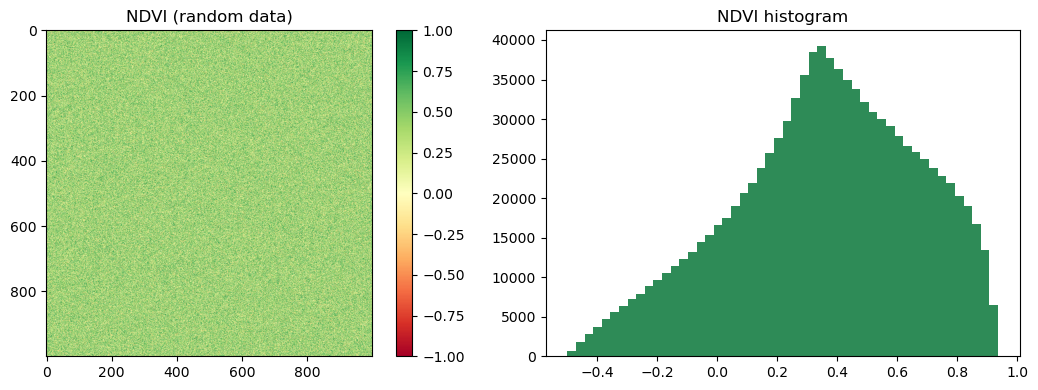

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im = axes[0].imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
axes[0].set_title("NDVI (random data)")
fig.colorbar(im, ax=axes[0])
axes[1].hist(ndvi.ravel(), bins=50, color="seagreen")
axes[1].set_title("NDVI histogram")
plt.tight_layout()

---
# Part 2 — Pandas

Pandas brings **labeled, heterogeneous tables** (`DataFrame`) to Python. Each column is a `Series`
(a NumPy array + an index). A GeoDataFrame (Part 3) is simply a DataFrame with a geometry column,
so everything here applies to vector data too.

Our dataset: the **27 Brazilian state capitals** (approximate values, IBGE Census 2022).
Let's first write it to a CSV file and then read it back as we would with any real file.

In [26]:
capitals = {
    "city": ["São Paulo", "Rio de Janeiro", "Brasília", "Fortaleza", "Salvador", "Belo Horizonte",
             "Manaus", "Curitiba", "Recife", "Goiânia", "Belém", "Porto Alegre", "São Luís",
             "Maceió", "Campo Grande", "Teresina", "João Pessoa", "Natal", "Cuiabá", "Aracaju",
             "Florianópolis", "Porto Velho", "Macapá", "Rio Branco", "Vitória", "Boa Vista", "Palmas"],
    "state": ["SP", "RJ", "DF", "CE", "BA", "MG", "AM", "PR", "PE", "GO", "PA", "RS", "MA", "AL", "MS",
              "PI", "PB", "RN", "MT", "SE", "SC", "RO", "AP", "AC", "ES", "RR", "TO"],
    "region": ["Sudeste", "Sudeste", "Centro-Oeste", "Nordeste", "Nordeste", "Sudeste", "Norte", "Sul",
               "Nordeste", "Centro-Oeste", "Norte", "Sul", "Nordeste", "Nordeste", "Centro-Oeste",
               "Nordeste", "Nordeste", "Nordeste", "Centro-Oeste", "Nordeste", "Sul", "Norte", "Norte",
               "Norte", "Sudeste", "Norte", "Norte"],
    "lat": [-23.55, -22.91, -15.79, -3.73, -12.97, -19.92, -3.12, -25.43, -8.05, -16.68, -1.46,
            -30.03, -2.53, -9.67, -20.47, -5.09, -7.12, -5.79, -15.60, -10.91, -27.59, -8.76,
            0.03, -9.97, -20.32, 2.82, -10.18],
    "lon": [-46.63, -43.17, -47.88, -38.52, -38.50, -43.94, -60.02, -49.27, -34.88, -49.25, -48.49,
            -51.23, -44.30, -35.74, -54.62, -42.80, -34.86, -35.21, -56.10, -37.07, -48.55, -63.90,
            -51.07, -67.81, -40.34, -60.67, -48.33],
    "population": [11451999, 6211223, 2817381, 2428708, 2418005, 2315560, 2063689, 1773718, 1488920,
                   1437366, 1303403, 1332845, 1037775, 957916, 898100, 866300, 833932, 751300,
                   650877, 602757, 537211, 460434, 442933, 364756, 322869, 413486, 302692],
    "area_km2": [1521, 1200, 5760, 312, 693, 331, 11401, 435, 218, 729, 1059, 495, 583, 509, 8083,
                 1391, 211, 167, 4327, 182, 675, 34091, 6563, 8835, 97, 5687, 2219],
    "elevation_m": [760, 5, 1172, 21, 8, 852, 92, 934, 4, 749, 10, 10, 4, 16, 592, 72, 37, 30, 165,
                    4, 3, 85, None, 153, 3, None, None],   # some values were "not collected"
}
pd.DataFrame(capitals).to_csv(DATA / "brazil_capitals.csv", index=False)

df = pd.read_csv(DATA / "brazil_capitals.csv")
df

,city,state,region,lat,lon,population,area_km2,elevation_m
0,São Paulo,SP,Sudeste,-23.55,-46.63,11451999,1521,760.0
1,Rio de Janeiro,RJ,Sudeste,-22.91,-43.17,6211223,1200,5.0
2,Brasília,DF,Centro-Oeste,-15.79,-47.88,2817381,5760,1172.0
3,Fortaleza,CE,Nordeste,-3.73,-38.52,2428708,312,21.0
4,Salvador,BA,Nordeste,-12.97,-38.50,2418005,693,8.0
5,Belo Horizonte,MG,Sudeste,-19.92,-43.94,2315560,331,852.0
6,Manaus,AM,Norte,-3.12,-60.02,2063689,11401,92.0
7,Curitiba,PR,Sul,-25.43,-49.27,1773718,435,934.0
8,Recife,PE,Nordeste,-8.05,-34.88,1488920,218,4.0
9,Goiânia,GO,Centro-Oeste,-16.68,-49.25,1437366,729,749.0


## 2.1 Essential operations: a first look at the data

In [27]:
df.head()        # first 5 rows (df.head(10) for 10); df.tail() for the last ones

,city,state,region,lat,lon,population,area_km2,elevation_m
0,São Paulo,SP,Sudeste,-23.55,-46.63,11451999,1521,760.0
1,Rio de Janeiro,RJ,Sudeste,-22.91,-43.17,6211223,1200,5.0
2,Brasília,DF,Centro-Oeste,-15.79,-47.88,2817381,5760,1172.0
3,Fortaleza,CE,Nordeste,-3.73,-38.52,2428708,312,21.0
4,Salvador,BA,Nordeste,-12.97,-38.50,2418005,693,8.0


In [28]:
df.info()        # column names, dtypes, non-null counts, memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         27 non-null     object 
 1   state        27 non-null     object 
 2   region       27 non-null     object 
 3   lat          27 non-null     float64
 4   lon          27 non-null     float64
 5   population   27 non-null     int64  
 6   area_km2     27 non-null     int64  
 7   elevation_m  24 non-null     float64
dtypes: float64(3), int64(2), object(3)
memory usage: 1.8+ KB


In [29]:
df.describe()    # summary statistics of numeric columns

,lat,lon,population,area_km2,elevation_m
count,27.00000,27.000000,2.700000e+01,27.000000,24.000000
mean,-12.39963,-47.153704,1.721709e+06,3621.259259,240.875000
std,9.01520,9.121861,2.292924e+06,6859.651626,369.678981
min,-30.03000,-67.810000,3.026920e+05,97.000000,3.000000
25%,-20.12000,-51.150000,5.699840e+05,383.000000,7.250000
50%,-10.18000,-47.880000,9.579160e+05,729.000000,33.500000
75%,-5.44000,-39.430000,1.918704e+06,5007.000000,271.750000
max,2.82000,-34.860000,1.145200e+07,34091.000000,1172.000000


In [30]:
print("shape  :", df.shape)            # (rows, columns)
print("columns:", df.columns.tolist())
print(df.dtypes)
df.describe(exclude="number")          # summary of the non-numeric (text) columns

shape  : (27, 8)
columns: ['city', 'state', 'region', 'lat', 'lon', 'population', 'area_km2', 'elevation_m']
city            object
state           object
region          object
lat            float64
lon            float64
population       int64
area_km2         int64
elevation_m    float64
dtype: object


,city,state,region
count,27,27,27
unique,27,27,5
top,São Paulo,SP,Nordeste
freq,1,1,9


## 2.2 Selection

* `df["col"]` → one column (`Series`); `df[["a", "b"]]` → several columns (`DataFrame`)
* `df.loc[rows, cols]` → by **label**
* `df.iloc[rows, cols]` → by **integer position**

In [31]:
df["city"].head(3)

0         São Paulo
1    Rio de Janeiro
2          Brasília
Name: city, dtype: object

In [32]:
df[["city", "population"]].head(3)

,city,population
0,São Paulo,11451999
1,Rio de Janeiro,6211223
2,Brasília,2817381


In [33]:
print(df.iloc[0])                       # first row, by position
df.iloc[:3, :4]                         # first 3 rows, first 4 columns

city           São Paulo
state                 SP
region           Sudeste
lat               -23.55
lon               -46.63
population      11451999
area_km2            1521
elevation_m        760.0
Name: 0, dtype: object


,city,state,region,lat
0,São Paulo,SP,Sudeste,-23.55
1,Rio de Janeiro,RJ,Sudeste,-22.91
2,Brasília,DF,Centro-Oeste,-15.79


In [34]:
dfc = df.set_index("city")              # use the city name as the row label
print(dfc.loc["Manaus", "population"])
dfc.loc[["Manaus", "Belém"], ["state", "population", "area_km2"]]

2063689


,state,population,area_km2
city,,,
Manaus,AM,2063689,11401
Belém,PA,1303403,1059


## 2.3 Filtering

A condition on a column creates a boolean `Series` — the very same idea as NumPy masks.

In [35]:
df[df["population"] > 2_000_000]

,city,state,region,lat,lon,population,area_km2,elevation_m
0,São Paulo,SP,Sudeste,-23.55,-46.63,11451999,1521,760.0
1,Rio de Janeiro,RJ,Sudeste,-22.91,-43.17,6211223,1200,5.0
2,Brasília,DF,Centro-Oeste,-15.79,-47.88,2817381,5760,1172.0
3,Fortaleza,CE,Nordeste,-3.73,-38.52,2428708,312,21.0
4,Salvador,BA,Nordeste,-12.97,-38.50,2418005,693,8.0
5,Belo Horizonte,MG,Sudeste,-19.92,-43.94,2315560,331,852.0
6,Manaus,AM,Norte,-3.12,-60.02,2063689,11401,92.0


In [36]:
# Several conditions: & | ~ and parentheses
df[(df["region"] == "Nordeste") & (df["population"] > 1_000_000)]

,city,state,region,lat,lon,population,area_km2,elevation_m
3,Fortaleza,CE,Nordeste,-3.73,-38.52,2428708,312,21.0
4,Salvador,BA,Nordeste,-12.97,-38.50,2418005,693,8.0
8,Recife,PE,Nordeste,-8.05,-34.88,1488920,218,4.0
12,São Luís,MA,Nordeste,-2.53,-44.30,1037775,583,4.0


In [37]:
print(df[df["state"].isin(["SP", "RJ", "MG", "ES"])]["city"].tolist())
print(df[df["city"].str.startswith("São")]["city"].tolist())

# .query() is often more readable
df.query("region == 'Sul' and elevation_m > 500")

['São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Vitória']
['São Paulo', 'São Luís']


,city,state,region,lat,lon,population,area_km2,elevation_m
7,Curitiba,PR,Sul,-25.43,-49.27,1773718,435,934.0


## 2.4 Creating attributes (new columns)

In [38]:
df["density"] = df["population"] / df["area_km2"]          # vectorized, like NumPy
df["pop_millions"] = (df["population"] / 1e6).round(2)
df["hemisphere"] = np.where(df["lat"] >= 0, "North", "South")
df["size_class"] = pd.cut(df["population"],
                          bins=[0, 500_000, 1_000_000, 2_000_000, np.inf],
                          labels=["< 500k", "500k-1M", "1M-2M", "> 2M"])
df["label"] = df["city"] + " (" + df["state"] + ")"

df.sort_values("density", ascending=False).head()[["label", "population", "area_km2", "density", "size_class"]]

,label,population,area_km2,density,size_class
3,Fortaleza (CE),2428708,312,7784.320513,> 2M
0,São Paulo (SP),11451999,1521,7529.256410,> 2M
5,Belo Horizonte (MG),2315560,331,6995.649547,> 2M
8,Recife (PE),1488920,218,6829.908257,1M-2M
1,Rio de Janeiro (RJ),6211223,1200,5176.019167,> 2M


## 2.5 Grouping (split → apply → combine)

In [39]:
df.groupby("region")["population"].sum().sort_values(ascending=False)

region
Sudeste         20301651
Nordeste        11385613
Centro-Oeste     5803724
Norte            5351393
Sul              3643774
Name: population, dtype: int64

In [40]:
summary = df.groupby("region").agg(
    n_capitals=("city", "count"),
    total_pop=("population", "sum"),
    mean_density=("density", "mean"),
    max_elevation=("elevation_m", "max"),
)
summary

,n_capitals,total_pop,mean_density,max_elevation
region,,,,
Centro-Oeste,4,5803724,680.589022,1172.0
Nordeste,9,11385613,3794.573117,72.0
Norte,7,5351393,249.027609,153.0
Sudeste,4,20301651,5757.367879,852.0
Sul,3,3643774,2521.998984,934.0


In [41]:
# transform: returns a value per ROW (same size as df) -> e.g. the share of each capital in its region
df["share_of_region"] = df["population"] / df.groupby("region")["population"].transform("sum")
df[["city", "region", "share_of_region"]].sort_values("share_of_region", ascending=False).head()

,city,region,share_of_region
0,São Paulo,Sudeste,0.564092
7,Curitiba,Sul,0.486780
2,Brasília,Centro-Oeste,0.485444
6,Manaus,Norte,0.385636
11,Porto Alegre,Sul,0.365787


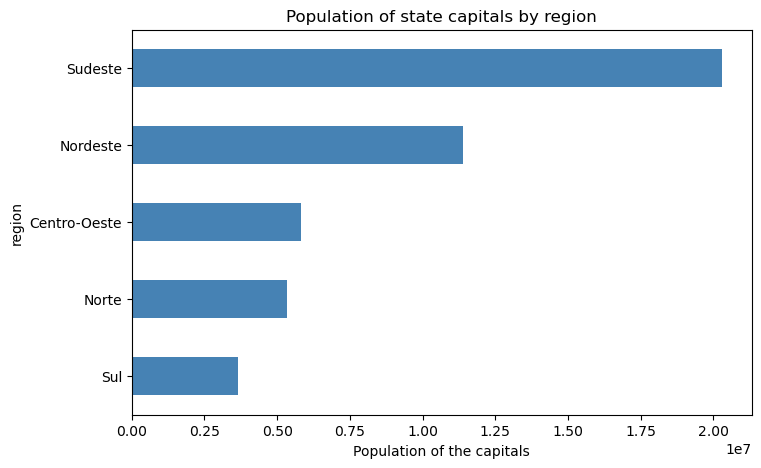

In [42]:
ax = summary["total_pop"].sort_values().plot.barh(color="steelblue")
ax.set_xlabel("Population of the capitals")
ax.set_title("Population of state capitals by region");

## 2.6 Joining tables

`pd.merge` combines tables through **common key columns** (like SQL `JOIN`).
In Part 3 we will see the *spatial* version: joining by **location** instead of by a key.

In [43]:
regions = pd.DataFrame({
    "region": ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"],
    "region_area_km2": [3_850_000, 1_552_000, 1_606_000, 924_600, 576_800],
    "n_states": [7, 9, 4, 4, 3],
})

merged = df.merge(regions, on="region", how="left", validate="many_to_one")
merged[["city", "region", "region_area_km2", "n_states"]].head()

,city,region,region_area_km2,n_states
0,São Paulo,Sudeste,924600,4
1,Rio de Janeiro,Sudeste,924600,4
2,Brasília,Centro-Oeste,1606000,4
3,Fortaleza,Nordeste,1552000,9
4,Salvador,Nordeste,1552000,9


In [44]:
# how= "inner" | "left" | "right" | "outer" -> what happens with keys that do not match?
extra = pd.DataFrame({"region": ["Sul", "Antarctica"], "note": ["cold", "very cold"]})
print(df.merge(extra, on="region", how="inner").shape)
print(df.merge(extra, on="region", how="left").shape)
print(df.merge(extra, on="region", how="outer").shape)

# pd.concat stacks tables (rows or columns)
pd.concat([df.head(2), df.tail(2)])[["city", "state"]]

(3, 15)
(27, 15)
(28, 15)


,city,state
0,São Paulo,SP
1,Rio de Janeiro,RJ
25,Boa Vista,RR
26,Palmas,TO


## 2.7 Missing values

Pandas represents missing data as `NaN` (or `pd.NA` / `NaT`). Most aggregations **skip** them by default.

In [45]:
print(df.isna().sum())
df[df["elevation_m"].isna()][["city", "state", "elevation_m"]]

city               0
state              0
region             0
lat                0
lon                0
population         0
area_km2           0
elevation_m        3
density            0
pop_millions       0
hemisphere         0
size_class         0
label              0
share_of_region    0
dtype: int64


,city,state,elevation_m
22,Macapá,AP,NaN
25,Boa Vista,RR,NaN
26,Palmas,TO,NaN


In [46]:
print("rows before dropna:", len(df), " after:", len(df.dropna(subset=["elevation_m"])))

# Fill with a constant, or with a statistic of the group (here: median elevation of the region)
df["elevation_filled"] = df["elevation_m"].fillna(
    df.groupby("region")["elevation_m"].transform("median")
)
df[df["elevation_m"].isna()][["city", "region", "elevation_m", "elevation_filled"]]

rows before dropna: 27  after: 24


,city,region,elevation_m,elevation_filled
22,Macapá,Norte,NaN,88.5
25,Boa Vista,Norte,NaN,88.5
26,Palmas,Norte,NaN,88.5


## 2.8 Read / write

| Format | Read | Write | Notes |
|---|---|---|---|
| CSV | `pd.read_csv` | `df.to_csv` | universal, but no types, large and slow |
| Excel | `pd.read_excel` | `df.to_excel` | needs `openpyxl` |
| Parquet | `pd.read_parquet` | `df.to_parquet` | columnar, compressed, typed — recommended for large data |
| SQL | `pd.read_sql` | `df.to_sql` | databases (PostgreSQL/PostGIS, SQLite, ...) |

In [47]:
df.to_csv(OUT / "capitals_enriched.csv", index=False)
df.to_parquet(OUT / "capitals_enriched.parquet")

for f in ["capitals_enriched.csv", "capitals_enriched.parquet"]:
    print(f"{f:28s} {os.path.getsize(OUT / f):>7,d} bytes")

back = pd.read_parquet(OUT / "capitals_enriched.parquet")
print(back.dtypes[["size_class", "density"]])   # Parquet keeps the dtypes (CSV would not)

capitals_enriched.csv          3,566 bytes
capitals_enriched.parquet     12,029 bytes
size_class    category
density        float64
dtype: object


---
# Part 3 — Vector data: Shapely, Fiona and GeoPandas

The Python vector ecosystem is built on top of C/C++ libraries:

```
           GeoPandas  (tables with geometries: pandas + everything below)
       ┌──────────────┼───────────────────┬────────────────┐
   Shapely          pyogrio / Fiona      pyproj           (matplotlib, folium...)
   geometries       file I/O             CRS & transforms
   (GEOS)           (GDAL/OGR)           (PROJ)
```

* **Shapely** — geometric objects and operations (`Point`, `LineString`, `Polygon`, buffer, intersection, ...).
  It is **planar**: it knows nothing about CRS, units or the Earth's curvature.
* **Fiona** — a Pythonic reader/writer of vector files, built on OGR. Since GeoPandas 1.0 the default I/O engine
  is **pyogrio** (much faster, vectorized), but Fiona is still widely used and supported (`engine="fiona"`).
* **pyproj** — interface to PROJ: coordinate reference systems and transformations.
* **GeoPandas** — ties everything together.

## 3.1 Shapely in one minute

shapely 2.1.1
POINT (-45.88 -23.18)
line length : 2.8284271247461903
square area : 4.0
contains    : True
intersects  : True
buffer area : 3.1365 (≈ pi: a polygon approximating a circle)


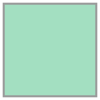

In [48]:
import shapely
from shapely.geometry import Point, LineString, Polygon

sjc = Point(-45.88, -23.18)                   # São José dos Campos -- ATTENTION: (x=lon, y=lat)
line = LineString([(0, 0), (1, 1), (2, 0)])
square = Polygon([(0, 0), (2, 0), (2, 2), (0, 2)])

print("shapely", shapely.__version__)
print(sjc.wkt)
print("line length :", line.length)
print("square area :", square.area)
print("contains    :", square.contains(Point(1, 1)))
print("intersects  :", square.intersects(line))
print("buffer area :", round(Point(0, 0).buffer(1).area, 4), "(≈ pi: a polygon approximating a circle)")
square

centroid inside?             False
representative_point inside? True


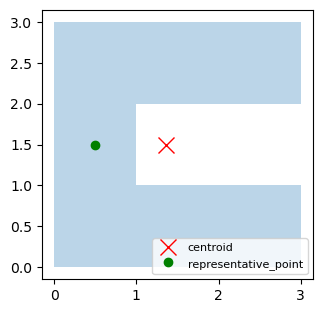

In [49]:
# centroid vs representative_point: the centroid of a concave polygon may fall OUTSIDE it
c_shape = Polygon([(0, 0), (3, 0), (3, 1), (1, 1), (1, 2), (3, 2), (3, 3), (0, 3)])
print("centroid inside?            ", c_shape.contains(c_shape.centroid))
print("representative_point inside?", c_shape.contains(c_shape.representative_point()))

fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.fill(*c_shape.exterior.xy, alpha=0.3)
ax.plot(*c_shape.centroid.xy, "rx", ms=12, label="centroid")
ax.plot(*c_shape.representative_point().xy, "go", label="representative_point")
ax.legend(loc="lower right", fontsize=8);

## 3.2 GeoPandas: how to turn a table into geospatial data?

A table with coordinates is **not yet** spatial data. We need:

1. a **geometry** column (Shapely objects);
2. a **CRS** telling what the coordinates mean.

Our capitals have `lon`/`lat` in degrees on WGS 84 → **EPSG:4326**.

In [50]:
import geopandas as gpd
import pyproj

print("geopandas", gpd.__version__, "| pyproj", pyproj.__version__, "| PROJ", pyproj.proj_version_str)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),   # x = lon, y = lat !
    crs="EPSG:4326",
)
gdf[["city", "state", "population", "geometry"]].head()

geopandas 1.1.1 | pyproj 3.7.2 | PROJ 9.5.1


,city,state,population,geometry
0,São Paulo,SP,11451999,POINT (-46.63 -23.55)
1,Rio de Janeiro,RJ,6211223,POINT (-43.17 -22.91)
2,Brasília,DF,2817381,POINT (-47.88 -15.79)
3,Fortaleza,CE,2428708,POINT (-38.52 -3.73)
4,Salvador,BA,2418005,POINT (-38.5 -12.97)


In [51]:
# Another common case: geometries stored as WKT text (e.g. from a database or a CSV export)
wkt_table = pd.DataFrame({
    "name": ["INPE - São José dos Campos", "Paraíba do Sul (segment)", "Study area"],
    "wkt": ["POINT (-45.86 -23.21)",
            "LINESTRING (-46.0 -23.3, -45.9 -23.2, -45.7 -23.1)",
            "POLYGON ((-46 -23.4, -45.6 -23.4, -45.6 -23.0, -46 -23.0, -46 -23.4))"],
})
wkt_gdf = gpd.GeoDataFrame(wkt_table, geometry=gpd.GeoSeries.from_wkt(wkt_table["wkt"]), crs="EPSG:4326")
wkt_gdf

,name,wkt,geometry
0,INPE - São José dos Campos,POINT (-45.86 -23.21),POINT (-45.86 -23.21)
1,Paraíba do Sul (segment),"LINESTRING (-46.0 -23.3, -45.9 -23.2, -45.7 -2...","LINESTRING (-46 -23.3, -45.9 -23.2, -45.7 -23.1)"
2,Study area,"POLYGON ((-46 -23.4, -45.6 -23.4, -45.6 -23.0,...","POLYGON ((-46 -23.4, -45.6 -23.4, -45.6 -23, -..."


## 3.3 `GeoDataFrame`, `GeoSeries` and `geometry`

* **`GeoDataFrame`**: a DataFrame with (at least) one geometry column — the *active* geometry.
* **`GeoSeries`**: a Series of geometries (+ CRS). Spatial methods (`area`, `buffer`, `centroid`, ...) live here.
* **`gdf.geometry`**: always returns the active geometry column, whatever its name.

In [52]:
print(type(gdf))
print(type(gdf.geometry), "| active geometry column:", gdf.geometry.name)
print(type(gdf["population"]))
print("geometry types:", gdf.geom_type.unique().tolist())
print("total bounds  :", gdf.total_bounds)        # [minx, miny, maxx, maxy]
gdf.geometry.x.head(3), gdf.geometry.y.head(3)

<class 'geopandas.geodataframe.GeoDataFrame'>
<class 'geopandas.geoseries.GeoSeries'> | active geometry column: geometry
<class 'pandas.core.series.Series'>
geometry types: ['Point']
total bounds  : [-67.81 -30.03 -34.86   2.82]


(0   -46.63
 1   -43.17
 2   -47.88
 dtype: float64,
 0   -23.55
 1   -22.91
 2   -15.79
 dtype: float64)

In [53]:
# All pandas operations still work -- the geometry comes along
big = gdf[gdf["population"] > 2_000_000]
print(type(big))
big[["city", "population", "geometry"]]

<class 'geopandas.geodataframe.GeoDataFrame'>


,city,population,geometry
0,São Paulo,11451999,POINT (-46.63 -23.55)
1,Rio de Janeiro,6211223,POINT (-43.17 -22.91)
2,Brasília,2817381,POINT (-47.88 -15.79)
3,Fortaleza,2428708,POINT (-38.52 -3.73)
4,Salvador,2418005,POINT (-38.5 -12.97)
5,Belo Horizonte,2315560,POINT (-43.94 -19.92)
6,Manaus,2063689,POINT (-60.02 -3.12)


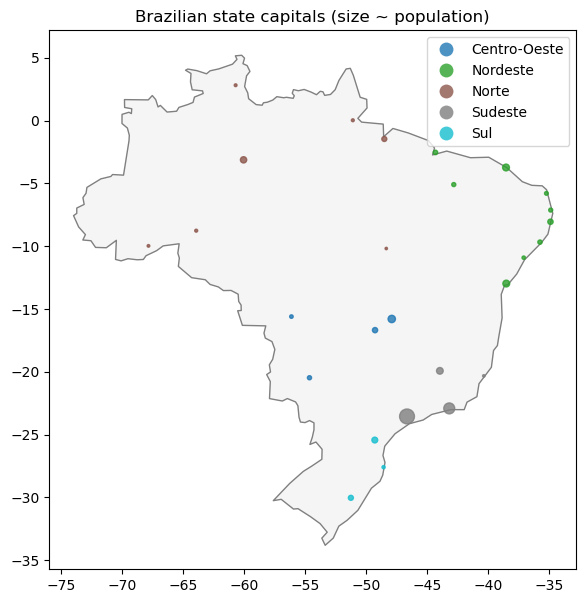

In [54]:
# Optional: a Brazil outline for context in maps (Natural Earth). Requires internet;
# if it fails, the maps below are simply drawn without it.
try:
    world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
    brazil = world[world["ADMIN"] == "Brazil"][["ADMIN", "geometry"]]
except Exception as e:
    print("Could not download Natural Earth:", e)
    brazil = None


def base_map(ax, crs=None):
    """Draw the Brazil outline (if available) in the given CRS."""
    if brazil is not None:
        b = brazil if crs is None else brazil.to_crs(crs)
        b.plot(ax=ax, color="whitesmoke", edgecolor="gray")
    return ax


def outline(ax, crs=None):
    """Draw only the Brazil boundary (on top of other layers)."""
    if brazil is not None:
        b = brazil if crs is None else brazil.to_crs(crs)
        b.boundary.plot(ax=ax, color="k", lw=0.8)
    return ax


ax = base_map(plt.subplots(figsize=(7, 7))[1])
gdf.plot(ax=ax, column="region", markersize=gdf["population"] / 1e5, legend=True, alpha=0.8)
ax.set_title("Brazilian state capitals (size ~ population)");

## 3.4 Reading and writing vector files

GeoPandas reads/writes (through GDAL/OGR) virtually any vector format.

| Format | Extension | Comments |
|---|---|---|
| **GeoPackage** | `.gpkg` | SQLite based, single file, multiple layers — recommended default |
| Shapefile | `.shp` + `.shx` + `.dbf` + `.prj` ... | legacy: 10-char column names, 2 GB limit, several files |
| GeoJSON | `.geojson` | text, web-friendly, always WGS 84 |
| **GeoParquet** | `.parquet` | columnar, fast, great for big data / cloud |
| FlatGeobuf | `.fgb` | streaming / cloud-friendly |

In [55]:
cols = ["city", "state", "region", "population", "area_km2", "elevation_m", "density", "geometry"]
gdf[cols].to_file(DATA / "brazil.gpkg", layer="capitals", driver="GPKG")
gdf[cols].to_file(OUT / "capitals.geojson", driver="GeoJSON")
gdf[cols].to_parquet(OUT / "capitals.parquet")

print(gpd.list_layers(DATA / "brazil.gpkg"))
capitals = gpd.read_file(DATA / "brazil.gpkg", layer="capitals")
capitals.head(3)

       name geometry_type
0  capitals         Point


,city,state,region,population,area_km2,elevation_m,density,geometry
0,São Paulo,SP,Sudeste,11451999,1521,760.0,7529.256410,POINT (-46.63 -23.55)
1,Rio de Janeiro,RJ,Sudeste,6211223,1200,5.0,5176.019167,POINT (-43.17 -22.91)
2,Brasília,DF,Centro-Oeste,2817381,5760,1172.0,489.128646,POINT (-47.88 -15.79)


In [56]:
# Reading only what you need: attribute filter, bounding box and columns
sudeste = gpd.read_file(DATA / "brazil.gpkg", layer="capitals",
                        where="region = 'Sudeste'", columns=["city", "population"])
print(sudeste)

in_bbox = gpd.read_file(DATA / "brazil.gpkg", layer="capitals", bbox=(-50, -25, -40, -15))
print(in_bbox["city"].tolist())

             city  population               geometry
0       São Paulo    11451999  POINT (-46.63 -23.55)
1  Rio de Janeiro     6211223  POINT (-43.17 -22.91)
2  Belo Horizonte     2315560  POINT (-43.94 -19.92)
3         Vitória      322869  POINT (-40.34 -20.32)
['São Paulo', 'Rio de Janeiro', 'Brasília', 'Belo Horizonte', 'Goiânia', 'Vitória']


### Fiona (a quick look)

Fiona exposes files as **iterators of GeoJSON-like records**. It is handy for streaming large files
feature by feature without loading everything into memory.

In [57]:
import fiona

with fiona.open(DATA / "brazil.gpkg", layer="capitals") as src:
    print("driver :", src.driver)
    print("crs    :", src.crs)
    print("schema :", src.schema)
    print("n feat :", len(src))
    feat = next(iter(src))
    print("first  :", dict(feat.properties), feat.geometry.coordinates)

driver : GPKG
crs    : EPSG:4326
schema : {'properties': {'city': 'str', 'state': 'str', 'region': 'str', 'population': 'int', 'area_km2': 'int', 'elevation_m': 'float', 'density': 'float'}, 'geometry': 'Point'}
n feat : 27
first  : {'city': 'São Paulo', 'state': 'SP', 'region': 'Sudeste', 'population': 11451999, 'area_km2': 1521, 'elevation_m': 760.0, 'density': 7529.25641025641} (-46.63, -23.55)


## 3.5 Coordinate Reference Systems: `crs` and `to_crs`

* **Geographic CRS** (e.g. EPSG:4326 — WGS 84, EPSG:4674 — SIRGAS 2000): coordinates in **degrees**
  on an ellipsoid. Great for storing/exchanging data, **bad for measuring** areas and distances.
* **Projected CRS** (e.g. UTM, Albers, Polyconic): coordinates in **meters** on a plane — every projection
  distorts something (area, shape, distance or direction).

Some useful CRS for Brazil:

| EPSG | Name | Use |
|---|---|---|
| 4674 | SIRGAS 2000 (geographic) | official Brazilian geodetic datum (IBGE) |
| 31983 | SIRGAS 2000 / UTM zone 23S | local/regional work (e.g. São Paulo state) |
| 5880 | SIRGAS 2000 / Brazil Polyconic | national maps |
| ESRI:102033 | South America Albers Equal Area Conic | **areas** at continental scale |

In [58]:
print(capitals.crs)
print("EPSG code   :", capitals.crs.to_epsg())
print("geographic? :", capitals.crs.is_geographic)
print("units       :", capitals.crs.axis_info[0].unit_name)
capitals.crs

EPSG:4326
EPSG code   : 4326
geographic? : True
units       : degree


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [59]:
cap_poly = capitals.to_crs(epsg=5880)          # Brazil Polyconic, meters
print(cap_poly.crs.name, "| units:", cap_poly.crs.axis_info[0].unit_name)
print(cap_poly.geometry.head(3))

SIRGAS 2000 / Brazil Polyconic | units: metre
0    POINT (5752163.887 7375218.358)
1    POINT (6110051.479 7424570.835)
2    POINT (5655637.917 8244065.991)
Name: geometry, dtype: geometry


> ⚠️ **`set_crs` vs `to_crs`**
> * `set_crs` only **labels** the data (use it when the CRS is missing but you know what it is). Coordinates do not change.
> * `to_crs` **transforms** the coordinates to another CRS.
>
> Using `set_crs` where `to_crs` was needed is one of the most common bugs in GIS!

In [60]:
wrong = capitals.set_crs(epsg=5880, allow_override=True)   # coordinates are still degrees!
print("wrong label  :", wrong.geometry.iloc[0])
print("right (to_crs):", cap_poly.geometry.iloc[0])

wrong label  : POINT (-46.63 -23.55)
right (to_crs): POINT (5752163.886888129 7375218.358203386)


In [61]:
# Distance Brasília -> São Paulo: degrees and projected meters
bsb = capitals.set_index("city").geometry
bsb_p = cap_poly.set_index("city").geometry

print(f"planar in degrees (meaningless): {bsb['Brasília'].distance(bsb['São Paulo']):.2f} °")
print(f"Brazil Polyconic               : {bsb_p['Brasília'].distance(bsb_p['São Paulo']) / 1000:.1f} km")

planar in degrees (meaningless): 7.86 °
Brazil Polyconic               : 874.2 km


## 3.6 Area

Let's build a regular grid of **5° × 5° cells** covering Brazil. In degrees all cells have the *same* "area",
but on the ground the area shrinks as we move away from the Equator.

In [62]:
from shapely.geometry import box

cells = []
for x in range(-75, -30, 5):
    for y in range(-35, 10, 5):
        cells.append({"cell_id": f"{x}_{y}", "geometry": box(x, y, x + 5, y + 5)})
grid = gpd.GeoDataFrame(cells, crs="EPSG:4326")
print(len(grid), "cells")

grid["area_deg2"] = grid.area            # GeoPandas warns: area in a geographic CRS!
grid.head(3)

81 cells


/tmp/ipykernel_8234/3989019928.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid["area_deg2"] = grid.area            # GeoPandas warns: area in a geographic CRS!


,cell_id,geometry,area_deg2
0,-75_-35,"POLYGON ((-70 -35, -70 -30, -75 -30, -75 -35, ...",25.0
1,-75_-30,"POLYGON ((-70 -30, -70 -25, -75 -25, -75 -30, ...",25.0
2,-75_-25,"POLYGON ((-70 -25, -70 -20, -75 -20, -75 -25, ...",25.0


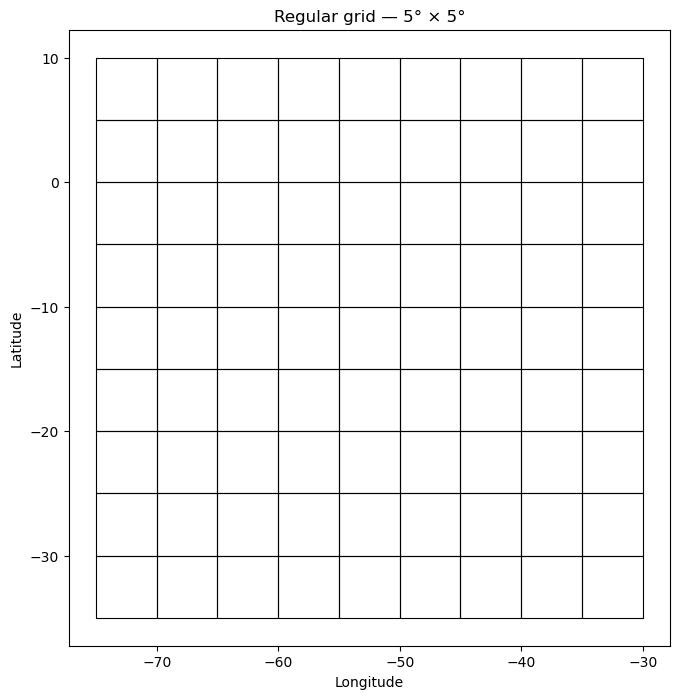

In [63]:
ax = grid.plot(
    figsize=(10, 8),
    edgecolor="black",
    facecolor="none",
    linewidth=0.8
)

ax.set_title("Regular grid — 5° × 5°")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [64]:
cells = []
xmin, xmax = -6_000_000, -4_000_000
ymin, ymax = -4_000_000, -2_000_000

cell_size = 5_000  # 5 km

for x in range(xmin, xmax, cell_size):
    for y in range(ymin, ymax, cell_size):
        cells.append({
            "cell_id": f"{x}_{y}",
            "geometry": box(x, y, x + cell_size, y + cell_size)
        })

grid = gpd.GeoDataFrame(
    cells,
    crs="ESRI:102033"
)

print(len(grid), "cells")

grid["area_km2"] = grid.area / 1e6

grid.head(3)

160000 cells


,cell_id,geometry,area_km2
0,-6000000_-4000000,"POLYGON ((-5995000 -4000000, -5995000 -3995000...",25.0
1,-6000000_-3995000,"POLYGON ((-5995000 -3995000, -5995000 -3990000...",25.0
2,-6000000_-3990000,"POLYGON ((-5995000 -3990000, -5995000 -3985000...",25.0


## 3.7 Buffer

A buffer is the region within a given distance of a geometry. **Always buffer in a projected CRS** —
`buffer(300000)` in EPSG:4326 would mean 300,000 **degrees**!

buffer area (km²): 282289  expected ≈ 282743


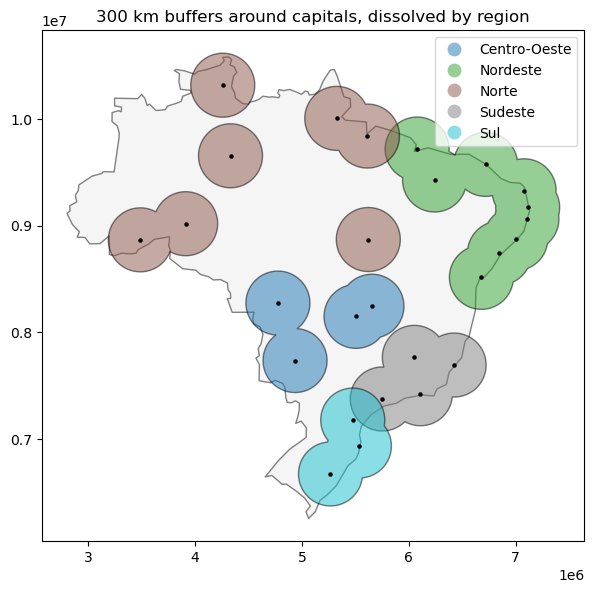

In [65]:
buffers = cap_poly.copy()
buffers["geometry"] = cap_poly.buffer(300_000)            # 300 km, CRS in meters
print("buffer area (km²):", round(buffers.area.iloc[0] / 1e6), " expected ≈", round(np.pi * 300**2))

# dissolve = the spatial "groupby": merges geometries of the same group
influence = buffers.dissolve(by="region", aggfunc={"population": "sum"}).reset_index()

ax = base_map(plt.subplots(figsize=(7, 7))[1], crs=cap_poly.crs)
influence.plot(ax=ax, column="region", alpha=0.5, edgecolor="k", legend=True)
cap_poly.plot(ax=ax, color="k", markersize=5)
ax.set_title("300 km buffers around capitals, dissolved by region");

## 3.8 Centroids

Like area and distance, the centroid should be computed in a **projected CRS**
(GeoPandas warns otherwise). Remember: for concave shapes, `representative_point()` is guaranteed
to be inside the polygon.

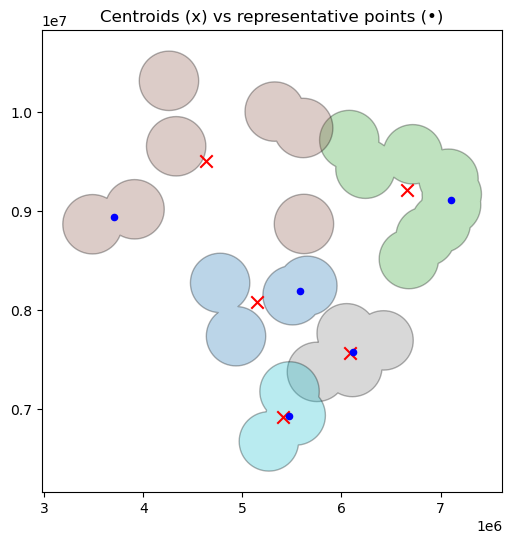

In [66]:
influence_centroids = influence.copy()
influence_centroids["geometry"] = influence.centroid

ax = influence.plot(column="region", alpha=0.3, edgecolor="k", figsize=(6, 6))
influence_centroids.plot(ax=ax, color="red", marker="x", markersize=80)
influence.representative_point().plot(ax=ax, color="blue", markersize=20)
ax.set_title("Centroids (x) vs representative points (•)");

## 3.9 Spatial join

A spatial join (`gpd.sjoin`) merges attributes of two layers based on a **spatial relationship**
(`intersects`, `within`, `contains`, `touches`, ...) instead of a common key.

In [67]:
cells = [
    {"cell_id": "A", "geometry": box(0, 0, 10, 10)},
    {"cell_id": "B", "geometry": box(10, 0, 20, 10)},
    {"cell_id": "C", "geometry": box(0, 10, 10, 20)},
    {"cell_id": "D", "geometry": box(10, 10, 20, 20)},
]
grid = gpd.GeoDataFrame(cells, crs="EPSG:4326")

hotspots = gpd.GeoDataFrame(
    {
        "hotspot_id": range(1, 9),
        "confidence": [85, 92, 71, 88, 65, 95, 79, 90],
    },
    geometry=[
        Point(2, 3),    # A
        Point(5, 7),    # A
        Point(8, 4),    # A
        Point(12, 6),   # B
        Point(17, 2),   # B
        Point(3, 15),   # C
        Point(8, 18),   # C
        Point(15, 16),  # D
    ],
    crs="EPSG:4326"
)

In [68]:
hotspots_grid = gpd.sjoin(
    hotspots,
    grid[["cell_id", "geometry"]],
    predicate="within",
    how="left"
)

print(hotspots_grid[["hotspot_id", "confidence", "cell_id"]])

   hotspot_id  confidence cell_id
0           1          85       A
1           2          92       A
2           3          71       A
3           4          88       B
4           5          65       B
5           6          95       C
6           7          79       C
7           8          90       D


In [69]:
counts = (
    hotspots_grid
    .groupby("cell_id")
    .size()
    .rename("hotspot_count")
)

grid = grid.join(counts, on="cell_id")

grid["hotspot_count"] = grid["hotspot_count"].fillna(0).astype(int)

print(grid[["cell_id", "hotspot_count"]])

  cell_id  hotspot_count
0       A              3
1       B              2
2       C              2
3       D              1


Text(0.5, 1.0, 'Focos de calor por célula')

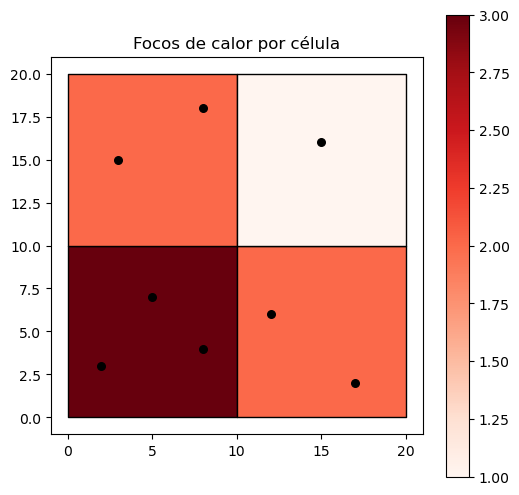

In [70]:
ax = grid.plot(
    column="hotspot_count",
    cmap="Reds",
    edgecolor="black",
    legend=True,
    figsize=(6, 6)
)

hotspots.plot(
    ax=ax,
    color="black",
    markersize=30
)

ax.set_title("Focos de calor por célula")

---
# Part 4 — OGR (command line)

**GDAL** (Geospatial Data Abstraction Library) is the translation engine behind almost every GIS software
(QGIS, ArcGIS, GRASS, PostGIS raster, Google Earth Engine ingestion...). Historically:

* **GDAL** → raster part
* **OGR** → vector part (*simple features*)

The command-line utilities are extremely useful for **scripting, automation and quick inspection**,
without writing any Python.

| Tool | Purpose |
|---|---|
| `ogrinfo` | vector **metadata**: layers, CRS, extent, fields, features |
| `ogr2ogr` | **converts** simple features data between file formats (+ reproject, filter, clip, SQL) |

> Since GDAL 3.11 there is also a new unified `gdal` command (`gdal vector info`, `gdal vector convert`,
> `gdal raster reproject`, ...). The classic tools shown here remain available and are what you will find in
> most scripts and tutorials.

In [71]:
!ogrinfo --version
!ogrinfo --formats | head -15

GDAL 3.8.5, released 2024/04/02
Supported Formats:
  FITS -raster,vector- (rw+): Flexible Image Transport System
  PCIDSK -raster,vector- (rw+v): PCIDSK Database File
  netCDF -raster,multidimensional raster,vector- (rw+vs): Network Common Data Format
  PDS4 -raster,vector- (rw+vs): NASA Planetary Data System 4
  VICAR -raster,vector- (rw+v): MIPL VICAR file
  JP2OpenJPEG -raster,vector- (rwv): JPEG-2000 driver based on OpenJPEG library
  PDF -raster,vector- (rw+vs): Geospatial PDF
  MBTiles -raster,vector- (rw+v): MBTiles
  TileDB -raster,multidimensional raster,vector- (rw+vs): TileDB
  BAG -raster,multidimensional raster,vector- (rw+v): Bathymetry Attributed Grid
  EEDA -vector- (ro): Earth Engine Data API
  OGCAPI -raster,vector- (rov): OGCAPI
  ESRI Shapefile -vector- (rw+v): ESRI Shapefile
  MapInfo File -vector- (rw+v): MapInfo File


## 4.1 `ogrinfo`

In [72]:
# List the layers of a dataset
!ogrinfo data/brazil.gpkg

INFO: Open of `data/brazil.gpkg'
      using driver `GPKG' successful.
1: capitals (Point)


In [73]:
# -so = summary only, -al = all layers: CRS, extent, feature count, fields
!ogrinfo -so -al data/brazil.gpkg

INFO: Open of `data/brazil.gpkg'
      using driver `GPKG' successful.

Layer name: capitals
Geometry: Point
Feature Count: 27
Extent: (-67.810000, -30.030000) - (-34.860000, 2.820000)
Layer SRS WKT:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        MEMBER["World Geodetic System 1984 (G2296)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            AN

In [74]:
# Show features, filtering by attribute (-where) and hiding geometries
!ogrinfo -al -geom=NO -where "population > 2000000" data/brazil.gpkg | tail -25

  state (String) = BA
  region (String) = Nordeste
  population (Integer64) = 2418005
  area_km2 (Integer64) = 693
  elevation_m (Real) = 8
  density (Real) = 3489.1847041847

OGRFeature(capitals):6
  city (String) = Belo Horizonte
  state (String) = MG
  region (String) = Sudeste
  population (Integer64) = 2315560
  area_km2 (Integer64) = 331
  elevation_m (Real) = 852
  density (Real) = 6995.64954682779

OGRFeature(capitals):7
  city (String) = Manaus
  state (String) = AM
  region (String) = Norte
  population (Integer64) = 2063689
  area_km2 (Integer64) = 11401
  elevation_m (Real) = 92
  density (Real) = 181.009472853258



In [75]:
# OGR speaks SQL!
!ogrinfo data/brazil.gpkg -sql "SELECT region, COUNT(*) AS n, SUM(population) AS pop FROM capitals GROUP BY region ORDER BY pop DESC"

INFO: Open of `data/brazil.gpkg'
      using driver `GPKG' successful.

Layer name: SELECT
Geometry: None
Feature Count: 5
Layer SRS WKT:
(unknown)
region: String (0.0)
n: Integer (0.0)
pop: Integer (0.0)
OGRFeature(SELECT):0
  region (String) = Sudeste
  n (Integer) = 4
  pop (Integer) = 20301651

OGRFeature(SELECT):1
  region (String) = Nordeste
  n (Integer) = 9
  pop (Integer) = 11385613

OGRFeature(SELECT):2
  region (String) = Centro-Oeste
  n (Integer) = 4
  pop (Integer) = 5803724

OGRFeature(SELECT):3
  region (String) = Norte
  n (Integer) = 7
  pop (Integer) = 5351393

OGRFeature(SELECT):4
  region (String) = Sul
  n (Integer) = 3
  pop (Integer) = 3643774



## 4.2 `ogr2ogr`

General syntax — note that the **output comes before the input**:

```bash
ogr2ogr [options] <output> <input> [layer]
```

In [76]:
# Format conversion: GeoPackage -> Shapefile
# (watch the warning: Shapefile column names are limited to 10 characters!)
!ogr2ogr -f "ESRI Shapefile" output/capitals.shp data/brazil.gpkg capitals
!ls output/capitals.*

Warning 6: Normalized/laundered field name: 'elevation_m' to 'elevation_'
output/capitals.dbf	 output/capitals.parquet  output/capitals.shp
output/capitals.geojson  output/capitals.prj	  output/capitals.shx


In [77]:
# Reprojection with -t_srs: WGS84 -> SIRGAS 2000 / Brazil Polyconic
!ogr2ogr -t_srs EPSG:5880 output/capitals_5880.shp output/capitals.shp
!ogrinfo -so -al output/capitals_5880.shp | grep -E "PROJCRS|Extent|Feature Count"

Feature Count: 27
Extent: (3486181.156633, 6673328.925608) - (7113729.640783, 10313945.705968)
PROJCRS["SIRGAS 2000 / Brazil Polyconic",


In [78]:
# ...and back to geographic coordinates (the classic one-liner)
!ogr2ogr -t_srs EPSG:4326 output/capitals_back_4326.shp output/capitals_5880.shp
!ogrinfo -so -al output/capitals_back_4326.shp | grep -E "GEOGCRS|Extent"

Extent: (-67.810000, -30.030000) - (-34.860000, 2.820000)
GEOGCRS["WGS 84",


In [79]:
# Attribute filter (-where), column selection (-select) and GeoJSON output
!ogr2ogr -f GeoJSON output/big_capitals.geojson data/brazil.gpkg capitals -where "population > 2000000" -select city,population
!head -c 400 output/big_capitals.geojson

{
"type": "FeatureCollection",
"name": "capitals",
"crs": { "type": "name", "properties": { "name": "urn:ogc:def:crs:OGC:1.3:CRS84" } },
"features": [
{ "type": "Feature", "properties": { "city": "São Paulo", "population": 11451999 }, "geometry": { "type": "Point", "coordinates": [ -46.63, -23.55 ] } },
{ "type": "Feature", "properties": { "city": "Rio de Janeiro", "population": 6211223 }, "geome

In [80]:
# SQL query + spatial filter by bounding box (-spat xmin ymin xmax ymax)
!ogr2ogr -f GPKG output/nordeste.gpkg data/brazil.gpkg -sql "SELECT city, state, population, geom FROM capitals WHERE region = 'Nordeste'" -nln nordeste
!ogr2ogr -f GPKG output/bbox.gpkg data/brazil.gpkg capitals -spat -50 -25 -40 -15
!ogrinfo -so -al output/bbox.gpkg | grep "Feature Count"

Feature Count: 6


In [81]:
# Export to CSV with coordinates as columns
!ogr2ogr -f CSV output/capitals_xy.csv data/brazil.gpkg capitals -lco GEOMETRY=AS_XY
!head -4 output/capitals_xy.csv

X,Y,city,state,region,population,area_km2,elevation_m,density
-46.63,-23.55,São Paulo,SP,Sudeste,11451999,1521,760,7529.25641025641
-43.17,-22.91,Rio de Janeiro,RJ,Sudeste,6211223,1200,5,5176.01916666667
-47.88,-15.79,Brasília,DF,Centro-Oeste,2817381,5760,1172,489.128645833333


## 4.3 The same in Python

The GDAL/OGR tools are also available from Python through the `osgeo` package:

* low-level API: `ogr.Open`, layers, features, fields;
* high-level "utility" functions: `gdal.VectorInfo` (≈ `ogrinfo`) and `gdal.VectorTranslate` (≈ `ogr2ogr`), which
  accept **the same options as the command line**.

In [82]:
from osgeo import gdal, ogr, osr
gdal.UseExceptions()                     # raise Python exceptions instead of returning None
print("GDAL", gdal.__version__)

ds = ogr.Open("data/brazil.gpkg")
for i in range(ds.GetLayerCount()):
    lyr = ds.GetLayer(i)
    srs = lyr.GetSpatialRef()
    print(lyr.GetName(), "|", lyr.GetFeatureCount(), "features |",
          ogr.GeometryTypeToName(lyr.GetGeomType()), "| EPSG:", srs.GetAuthorityCode(None))

lyr = ds.GetLayerByName("capitals")
defn = lyr.GetLayerDefn()
print([defn.GetFieldDefn(i).GetName() for i in range(defn.GetFieldCount())])
print("extent (xmin, xmax, ymin, ymax):", lyr.GetExtent())

lyr.SetAttributeFilter("population > 2000000")
for feat in lyr:
    print(f"{feat.GetField('city'):16s} {feat.GetGeometryRef().ExportToWkt()}")
ds = None                                # close the dataset

GDAL 3.10.2
capitals | 27 features | Point | EPSG: 4326
['city', 'state', 'region', 'population', 'area_km2', 'elevation_m', 'density']
extent (xmin, xmax, ymin, ymax): (-67.81, -34.86, -30.03, 2.82)
São Paulo        POINT (-46.63 -23.55)
Rio de Janeiro   POINT (-43.17 -22.91)
Brasília         POINT (-47.88 -15.79)
Fortaleza        POINT (-38.52 -3.73)
Salvador         POINT (-38.5 -12.97)
Belo Horizonte   POINT (-43.94 -19.92)
Manaus           POINT (-60.02 -3.12)


In [83]:
# ogrinfo / ogr2ogr from Python
print(gdal.VectorInfo("data/brazil.gpkg", format="text", options="-so -al")[:500])

gdal.VectorTranslate("output/capitals_5880_py.gpkg", "data/brazil.gpkg",
                     format="GPKG", dstSRS="EPSG:5880", layers=["capitals"])
print(gpd.read_file("output/capitals_5880_py.gpkg").crs.name)

# Or pass the command-line options as a string
gdal.VectorTranslate("output/sul.geojson", "data/brazil.gpkg", options="-f GeoJSON -where \"region='Sul'\"")
print(gpd.read_file("output/sul.geojson")["city"].tolist())

INFO: Open of `data/brazil.gpkg'
      using driver `GPKG' successful.

Layer name: capitals
Geometry: Point
Feature Count: 27
Extent: (-67.810000, -30.030000) - (-34.860000, 2.820000)
Layer SRS WKT:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER
SIRGAS 2000 / Brazil Polyconic
['Curitiba', 'Porto Alegre', 'Florianópolis']


> In day-to-day data science work, `geopandas.read_file` / `to_file` cover most needs. The OGR tools shine for
> **batch conversions, huge files (streaming, no need to fit in memory), databases (PostGIS)** and shell pipelines.

---
# Part 5 — GDAL (command line)

## 5.1 `gdalinfo` — raster metadata

Driver, size, CRS, **geotransform** (origin and pixel size), corner coordinates, bands, dtype, nodata...

In [84]:
!gdalinfo "https://data.inpe.br/bdc/data/topodata/v001/23S/465/23S465SN.tif"

Driver: GTiff/GeoTIFF
Files: none associated
Size is 5400, 4500
Coordinate System is:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        MEMBER["World Geodetic System 1984 (G2296)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["geodetic longitude (Lon)",east,
            ORDER[2],
       

In [85]:
!gdalinfo -stats "/vsicurl/https://data.inpe.br/bdc/data/topodata/v001/23S/465/23S465SN.tif"

Driver: GTiff/GeoTIFF
Files: /vsicurl/https://data.inpe.br/bdc/data/topodata/v001/23S/465/23S465SN.tif
Size is 5400, 4500
Coordinate System is:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        MEMBER["World Geodetic System 1984 (G2296)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["geo

In [86]:
!gdalinfo -hist "https://data.inpe.br/bdc/data/topodata/v001/23S/465/23S465SN.tif"

Driver: GTiff/GeoTIFF
Files: none associated
Size is 5400, 4500
Coordinate System is:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        MEMBER["World Geodetic System 1984 (G2296)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["geodetic longitude (Lon)",east,
            ORDER[2],
       

In [87]:
!gdalinfo -json "https://data.inpe.br/bdc/data/topodata/v001/23S/465/23S465SN.tif"

{
  "description":"https://data.inpe.br/bdc/data/topodata/v001/23S/465/23S465SN.tif",
  "driverShortName":"GTiff",
  "driverLongName":"GeoTIFF",
  "files":[],
  "size":[
    5400,
    4500
  ],
  "coordinateSystem":{
    "wkt":"GEOGCRS[\"WGS 84\",\n    ENSEMBLE[\"World Geodetic System 1984 ensemble\",\n        MEMBER[\"World Geodetic System 1984 (Transit)\"],\n        MEMBER[\"World Geodetic System 1984 (G730)\"],\n        MEMBER[\"World Geodetic System 1984 (G873)\"],\n        MEMBER[\"World Geodetic System 1984 (G1150)\"],\n        MEMBER[\"World Geodetic System 1984 (G1674)\"],\n        MEMBER[\"World Geodetic System 1984 (G1762)\"],\n        MEMBER[\"World Geodetic System 1984 (G2139)\"],\n        MEMBER[\"World Geodetic System 1984 (G2296)\"],\n        ELLIPSOID[\"WGS 84\",6378137,298.257223563,\n            LENGTHUNIT[\"metre\",1]],\n        ENSEMBLEACCURACY[2.0]],\n    PRIMEM[\"Greenwich\",0,\n        ANGLEUNIT[\"degree\",0.0174532925199433]],\n    CS[ellipsoidal,2],\n        AX

## 5.2 `gdal_translate` — convert between formats (and subset, rescale, compress...)

In [88]:
# Compression NONE
!gdal_translate -q -co COMPRESS=NONE -co PREDICTOR=3 -co TILED=YES "https://data.inpe.br/bdc/data/topodata/v001/23S/465/23S465SN.tif" data/dem.tif

# Compression and tiling (PREDICTOR=3 = floating-point predictor; use 2 for integer data)
!gdal_translate -q -co COMPRESS=DEFLATE -co PREDICTOR=3 -co TILED=YES data/dem.tif output/dem_deflate.tif

# Cloud Optimized GeoTIFF (COG): tiled + overviews + HTTP range-request friendly
!gdal_translate -q -of COG -co COMPRESS=DEFLATE -co PREDICTOR=YES data/dem.tif output/dem_cog.tif

!ls -lh data/dem.tif output/dem_deflate.tif output/dem_cog.tif

-rw-r--r-- 1 jovyan users 100M Sep 28 12:34 data/dem.tif
-rw-r--r-- 1 jovyan users 100M Sep 28 12:34 output/dem_cog.tif
-rw-r--r-- 1 jovyan users  74M Sep 28 12:34 output/dem_deflate.tif


In [89]:
# Subset by pixel window (-srcwin xoff yoff xsize ysize) or by coordinates (-projwin ulx uly lrx lry)
!gdal_translate -q -srcwin 0 0 200 150 data/dem.tif output/dem_subset_px.tif
!gdal_translate -q -projwin 400000 7445000 410000 7438000 data/dem.tif output/dem_subset_xy.tif

# Resample to 25% of the size
!gdal_translate -q -outsize 25% 25% -r average data/dem.tif output/dem_small.tif

# Select / reorder bands: false color composite (NIR, Red, Green)
!gdal_translate -q -b 4 -b 3 -b 2 data/multispectral.tif output/false_color.tif

# To an 8-bit PNG (scaled 500..2000 m -> 0..255), e.g. for a quick figure or web
!gdal_translate -q -of PNG -ot Byte -scale 500 2000 0 255 data/dem.tif output/dem.png

!gdalinfo output/dem_subset_xy.tif | grep -E "Size is|Origin|Pixel Size"
!gdalinfo output/false_color.tif | grep -E "Band [0-9]"

ERROR 3: output/dem_subset_xy.tif: Free disk space available is 1034242142208 bytes, whereas 3628790827200000 are at least necessary. You can disable this check by defining the CHECK_DISK_FREE_SPACE configuration option to FALSE.
ERROR 4: data/multispectral.tif: No such file or directory
Warning 1: for band 1, nodata value has been clamped to 0, the original value being out of range.
ERROR 4: output/dem_subset_xy.tif: No such file or directory
gdalinfo failed - unable to open 'output/dem_subset_xy.tif'.
ERROR 4: output/false_color.tif: No such file or directory
gdalinfo failed - unable to open 'output/false_color.tif'.


## 5.3 `gdalwarp` — reprojection, resampling, mosaicking and clipping

In [90]:
# Reproject to geographic coordinates
!gdalwarp -q -overwrite -t_srs EPSG:4326 -r bilinear data/dem.tif output/dem_4326.tif
!gdalinfo output/dem_4326.tif | grep -E "Size is|Pixel Size|GEOGCRS"

Size is 5400, 4500
GEOGCRS["WGS 84",
Pixel Size = (0.000277778193079,-0.000277778193079)


In [91]:
# Take long to run

# # Change resolution (30 m -> 90 m); choose the resampling method carefully:
# #   nearest -> categorical data (land cover classes); bilinear/cubic/average -> continuous data
# !gdalwarp -q -overwrite -tr 90 90 -r average data/dem.tif output/dem_90m.tif
# !gdalinfo output/dem_90m.tif | grep -E "Size is|Pixel Size"

In [92]:
# Take long to run

# # Clip by a polygon (cutline)
# !gdalwarp -q -overwrite -cutline data/aoi.gpkg -crop_to_cutline -dstnodata -9999 data/dem.tif output/dem_aoi.tif
# !gdalinfo output/dem_aoi.tif | grep -E "Size is"

## 5.4 `gdal_merge` — mosaicking

`gdal_merge.py` merges several rasters into one (the tiles must share CRS and band layout).
With `-separate`, each input becomes a **separate band** (layer stacking).

> Tip: `gdalbuildvrt` creates a **virtual** mosaic (a small XML file pointing to the tiles) — no data is copied,
> and any GDAL tool can read it.

In [93]:
!gdal_merge.py -q -o output/dem_merged.tif -n -9999 -a_nodata -9999 data/dem_tile_left.tif data/dem_tile_right.tif
!gdalinfo output/dem_merged.tif | grep -E "Size is|Origin"

!gdalbuildvrt -q output/dem_mosaic.vrt data/dem_tile_left.tif data/dem_tile_right.tif
!head -12 output/dem_mosaic.vrt

Traceback (most recent call last):
  File "/opt/conda/bin/gdal_merge.py", line 14, in <module>
    sys.exit(main(sys.argv))
             ^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/osgeo_utils/gdal_merge.py", line 650, in main
    return gdal_merge(argv)
           ^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/osgeo_utils/gdal_merge.py", line 525, in gdal_merge
    file_infos = names_to_fileinfos(names)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/osgeo_utils/gdal_merge.py", line 213, in names_to_fileinfos
    if fi.init_from_name(name) == 1:
       ^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/osgeo_utils/gdal_merge.py", line 247, in init_from_name
    fh = gdal.Open(filename)
         ^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/osgeo/gdal.py", line 6003, in Open
    return _gdal.Open(*args)
           ^^^^^^^^^^^^^^^^^
RuntimeError: data/dem_tile_left.

## 5.5 `gdal_calc` — raster calculator

Band algebra with NumPy syntax. Inputs are named `-A`, `-B`, ... (with `--A_band`, `--B_band` to choose bands).

In [94]:
# NDVI = (NIR - Red) / (NIR + Red)  -> NIR is band 4, Red is band 3
!gdal_calc.py --quiet --overwrite -A data/multispectral.tif --A_band=4 -B data/multispectral.tif --B_band=3 \
    --outfile=output/ndvi.tif --type=Float32 --NoDataValue=-9999 \
    --calc="(A.astype(float) - B) / (A.astype(float) + B)"

# A binary mask: areas above 1000 m
!gdal_calc.py --quiet --overwrite -A data/dem.tif --outfile=output/dem_above_1000.tif --type=Byte \
    --calc="A > 1000"

!gdalinfo -stats output/ndvi.tif | grep -E "STATISTICS_(MIN|MAX|MEAN)"

Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/osgeo_utils/auxiliary/gdal_argparse.py", line 226, in main
    self.doit(**kwargs)
  File "/opt/conda/lib/python3.11/site-packages/osgeo_utils/gdal_calc.py", line 887, in doit
    return Calc(**kwargs)
           ^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/osgeo_utils/gdal_calc.py", line 240, in Calc
    myFile = open_ds(filename)
             ^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/osgeo_utils/auxiliary/util.py", line 125, in open_ds
    return ods.__enter__()
           ^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/osgeo_utils/auxiliary/util.py", line 244, in __enter__
    self.ds = self._open_ds(self.filename, *self.args, **self.kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/osgeo_utils/auxiliary/util.py", line 303, in _open_ds
    return gdal.OpenEx(str(filenam

---
# Part 6 — GDAL in Python

The `osgeo.gdal` module is a thin (SWIG-generated) wrapper around the C++ API: very complete and powerful,
but not very "Pythonic". Here is a minimal command-line script:

In [95]:
%%writefile raster_info.py
from osgeo import gdal
import sys

gdal.UseExceptions()

ds = gdal.Open(sys.argv[1])
print(f"Width: {ds.RasterXSize}")
print(f"Height: {ds.RasterYSize}")
print(f"Number of bands: {ds.RasterCount}")

array = ds.GetRasterBand(1).ReadAsArray()
print(array)

Overwriting raster_info.py


In [96]:
!python raster_info.py data/dem.tif

Width: 5400
Height: 4500
Number of bands: 1
[[28.054333   24.566633   23.783146   ... 48.367527   45.127167
  42.271008  ]
 [26.053888   23.7479     23.628197   ... 42.520985   44.46893
  38.124405  ]
 [23.755981   23.446817   23.204254   ... 30.655872   37.06784
  36.705082  ]
 ...
 [ 1.054506    1.1315974   1.1278334  ...  4.032667    3.4974
   1.7477654 ]
 [ 1.5041674   1.2548562   1.3003577  ...  3.4581017   2.469211
   0.87800527]
 [ 1.1454586   0.8867913   1.5788267  ...  2.1504123   2.4704947
   1.3478321 ]]


## 6.1 Dataset → Band → Array

The **geotransform** is a tuple of 6 coefficients mapping pixel (col, row) to map coordinates (x, y):

```
x = GT[0] + col * GT[1] + row * GT[2]
y = GT[3] + col * GT[4] + row * GT[5]
```

`GT[0], GT[3]` = upper-left corner; `GT[1]` = pixel width; `GT[5]` = pixel height (**negative**, since rows go down);
`GT[2], GT[4]` = rotation (usually 0).

In [97]:
ds = gdal.Open("data/dem.tif")
print("Driver     :", ds.GetDriver().ShortName)
print("Size       :", ds.RasterXSize, "x", ds.RasterYSize, "x", ds.RasterCount)
gt = ds.GetGeoTransform()
print("GeoTransform:", gt)

srs = osr.SpatialReference(wkt=ds.GetProjection())
print("CRS        :", srs.GetName(), "| EPSG:", srs.GetAuthorityCode(None))

band = ds.GetRasterBand(1)
print("Data type  :", gdal.GetDataTypeName(band.DataType))
print("NoData     :", band.GetNoDataValue())
print("Stats      :", band.ComputeStatistics(False))    # [min, max, mean, std], ignoring nodata

# Pixel -> map coordinates
col, row = 100, 50
x = gt[0] + col * gt[1] + row * gt[2]
y = gt[3] + col * gt[4] + row * gt[5]
print(f"pixel (col={col}, row={row}) -> x={x}, y={y}")

Driver     : GTiff
Size       : 5400 x 4500 x 1
GeoTransform: (-46.5, 0.0002777784814814818, 0.0, -23.0, 0.0, -0.0002777777777777778)
CRS        : WGS 84 | EPSG: 4326
Data type  : Float32
NoData     : -9999.0
Stats      : [0.0, 381.64013671875, 16.62099006740942, 16.89175617950065]
pixel (col=100, row=50) -> x=-46.47222215185185, y=-23.01388888888889


In [98]:
arr = band.ReadAsArray()                             # the full band as a NumPy array
print(arr.shape, arr.dtype)
print("naive mean (includes -9999!):", arr.mean())
print("valid mean                  :", arr[arr != band.GetNoDataValue()].mean())

# Read only a window: ReadAsArray(xoff, yoff, xsize, ysize)
win = band.ReadAsArray(100, 50, 5, 4)
print(win)

(4500, 5400) float32
naive mean (includes -9999!): 16.620987
valid mean                  : 16.620987
[[16.205795  13.368015   9.420291   5.813799   3.314    ]
 [18.910292  17.078543  14.789304   8.642873   5.5171676]
 [19.515333  18.251778  17.596546  14.992447  12.8039   ]
 [20.530474  20.76429   19.691832  18.745113  16.521694 ]]


## 6.2 Writing a raster with GDAL

Steps: get a driver → `Create` → set geotransform and projection → write the array → **close the dataset**
(setting it to `None` flushes the data to disk; forgetting this is a classic bug).

In [99]:
# Classify slope into 3 classes: 0 = flat (< 8°), 1 = moderate (8-20°), 2 = steep (> 20°)
slope_ds = gdal.Open("https://data.inpe.br/bdc/data/topodata/v001/23S/465/23S465SN.tif")
slope = slope_ds.GetRasterBand(1).ReadAsArray()
slope_nodata = slope_ds.GetRasterBand(1).GetNoDataValue()
slope_cls = np.digitize(slope, [8, 20]).astype(np.uint8)
slope_cls[slope == slope_nodata] = 255

driver = gdal.GetDriverByName("GTiff")
out = driver.Create("output/slope_classes.tif", slope_ds.RasterXSize, slope_ds.RasterYSize, 1,
                    gdal.GDT_Byte, options=["COMPRESS=DEFLATE"])
out.SetGeoTransform(slope_ds.GetGeoTransform())
out.SetProjection(slope_ds.GetProjection())
out_band = out.GetRasterBand(1)
out_band.WriteArray(slope_cls)
out_band.SetNoDataValue(255)
out = None                                  # close -> flush to disk
slope_ds = None

print(np.unique(slope_cls, return_counts=True))

(array([0, 1, 2], dtype=uint8), array([11249459,  4337047,  8713494]))


---
# Part 7 — Rasterio

Rasterio also uses GDAL underneath, but offers a **Pythonic API**: context managers (`with`), NumPy arrays,
`Affine` transforms, integration with Shapely/GeoPandas. It is the base of many higher-level tools
(`rioxarray`, `rasterstats`, `torchgeo`...).

## 7.1 Opening a dataset and reading its metadata

In [100]:
import rasterio

print("rasterio", rasterio.__version__, "| GDAL", rasterio.__gdal_version__)

img_url = "https://data.inpe.br/bdc/data/S2_L2A/v001/20/L/LP/2026/09/S2B_TCI_20260924T143739_N0513_R096_T20LLP_20260924T181207.tif"
with rasterio.open(img_url) as src:
    print("width    :", src.width)
    print("height   :", src.height)
    print("count    :", src.count)          # number of bands
    print("crs      :", src.crs)
    print("transform:\n", src.transform)
    print("bounds   :", src.bounds)
    print("dtypes   :", src.dtypes)
    print("nodata   :", src.nodata)
    print("res      :", src.res)
    print("profile  :", src.profile)

rasterio 1.4.3 | GDAL 3.9.3
width    : 10980
height   : 10980
count    : 3
crs      : EPSG:32720
transform:
 | 10.00, 0.00, 300000.00|
| 0.00,-10.00, 8900020.00|
| 0.00, 0.00, 1.00|
bounds   : BoundingBox(left=300000.0, bottom=8790220.0, right=409800.0, top=8900020.0)
dtypes   : ('uint8', 'uint8', 'uint8')
nodata   : None
res      : (10.0, 10.0)
profile  : {'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 10980, 'height': 10980, 'count': 3, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 20S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["E

## 7.2 `read`

In [101]:
band1 = rasterio.open(img_url).read(1)                # (rows, cols) -- bands are 1-based!
print(band1.shape, band1.shape, band1.dtype)

with rasterio.open(img_url) as ms_src:
    green, red = ms_src.read([2, 3]).astype(np.float32)
    print("multispectral:", ms_src.count, "bands", ms_src.dtypes, "| band descriptions:", ms_src.descriptions)

(10980, 10980) (10980, 10980) uint8
multispectral: 3 bands ('uint8', 'uint8', 'uint8') | band descriptions: (None, None, None)


In [102]:
band1

array([[ 99,  99, 102, ...,   0,   0,   0],
       [100,  98, 102, ...,   0,   0,   0],
       [100, 100, 100, ...,   0,   0,   0],
       ...,
       [ 23,  20,  24, ...,   0,   0,   0],
       [ 20,  21,  26, ...,   0,   0,   0],
       [ 20,  23,  26, ...,   0,   0,   0]], dtype=uint8)

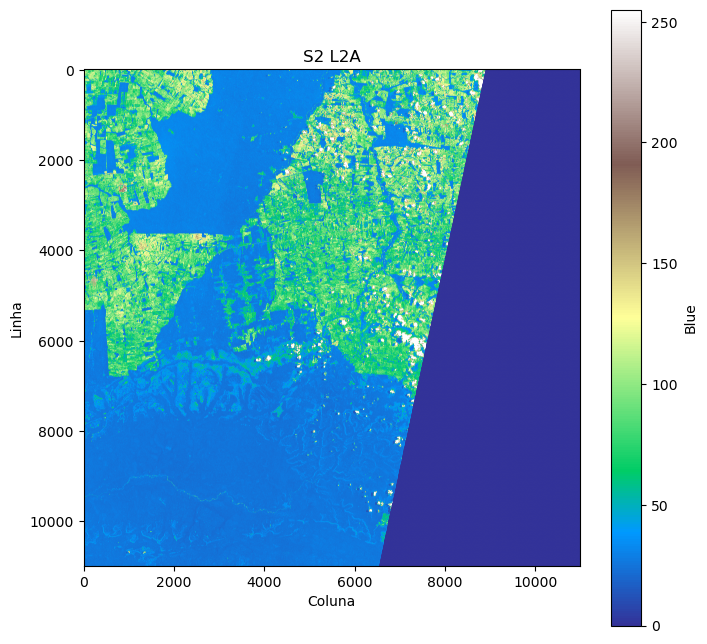

In [103]:
plt.figure(figsize=(8, 8))

plt.imshow(
    band1,
    cmap="terrain"
)

plt.colorbar(label="Blue")
plt.title("S2 L2A")
plt.xlabel("Coluna")
plt.ylabel("Linha")

plt.show()

## 7.3 `masked=True` — handling nodata automatically

With `masked=True` Rasterio returns a `numpy.ma.MaskedArray` in which *nodata* pixels are masked out,
so statistics are correct without extra work.

In [104]:
img_url2 = "https://data.inpe.br/bdc/data/s2-16d/v2/001/014/2026/08/13/S2-16D_V2_001014_20260813_B01.tif"
with rasterio.open(img_url2) as src:
    blue = src.read(1)

In [105]:
with rasterio.open(img_url2) as src:
    blue_m = src.read(1, masked=True)
    print(type(blue_m))
    print("masked pixels:", blue_m.mask.sum())
    print(f"mean without mask: {blue.mean():9.2f}")
    print(f"mean with mask   : {blue_m.mean():9.2f}")
    print(f"min / max        : {blue_m.min():.1f} / {blue_m.max():.1f}")

    # The dataset-level mask (255 = valid, 0 = nodata)
    print(np.unique(src.dataset_mask(), return_counts=True))

<class 'numpy.ma.core.MaskedArray'>
masked pixels: 85614915
mean without mask:     48.62
mean with mask   :    209.35
min / max        : 18.0 / 9520.0
(array([  0, 255], dtype=uint8), array([85614915, 25898685]))


# Same think with previous image

In [106]:
with rasterio.open(img_url) as src:
    tci_blue = src.read(1)

In [107]:
with rasterio.open(img_url) as src:
    tci_blue_m = src.read(1, masked=True)
    print(type(blue_m))
    print("masked pixels:", tci_blue_m.mask.sum())
    print(f"mean without mask: {tci_blue.mean():9.2f}")
    print(f"mean with mask   : {tci_blue_m.mean():9.2f}")
    print(f"min / max        : {tci_blue_m.min():.1f} / {tci_blue_m.max():.1f}")

    # The dataset-level mask (255 = valid, 0 = nodata)
    print(np.unique(src.dataset_mask(), return_counts=True))

<class 'numpy.ma.core.MaskedArray'>
masked pixels: 0
mean without mask:     35.94
mean with mask   :     35.94
min / max        : 0.0 / 255.0
(array([255], dtype=uint8), array([120560400]))


## 7.4 `Window` — reading only a piece of a raster

Essential for **large images** that do not fit in memory, and for tiling images (e.g. for deep learning).
`Window(col_off, row_off, width, height)`.

In [108]:
from rasterio.windows import Window, from_bounds

src = rasterio.open(img_url)
    
win = Window(col_off=100, row_off=50, width=200, height=150)
sub = src.read(1, window=win, masked=True)
print("window shape:", sub.shape)

win_transform = src.window_transform(win)     # the georeferencing of the window
print("window origin:", win_transform.c, win_transform.f)

# A window from map coordinates
win2 = from_bounds(401000, 7438000, 407000, 7444000, transform=src.transform)
print(win2)

# Save the window as a new GeoTIFF: copy the profile and update what changed
profile = src.profile.copy()
profile.update(width=win.width, height=win.height, transform=win_transform, compress="deflate")
with rasterio.open("output/dem_window.tif", "w", **profile) as dst:
    dst.write(src.read(1, window=win), 1)

window shape: (150, 200)
window origin: 301000.0 8899520.0
Window(col_off=10100.0, row_off=145602.0, width=600.0, height=600.0)


In [109]:
# Processing block by block (windows follow the internal tiling/striping of the file)
maxima = [src.read(1, window=w, masked=True).max() for _, w in src.block_windows(1)]
print(len(maxima), "blocks | global max:", max(m for m in maxima if m is not np.ma.masked))

# Or regular tiles, e.g. 256 x 256 chips for a CNN
chips = [Window(c, r, 256, 256) for r in range(0, src.height - 255, 256) for c in range(0, src.width - 255, 256)]
print(len(chips), "full 256x256 chips")

484 blocks | global max: 255
1764 full 256x256 chips


## 7.5 Putting it together: NDVI, sampling and clipping with vectors

In [110]:
red_url = "https://data.inpe.br/bdc/data/S2_L2A/v001/22/J/BN/2025/07/S2B_B04_20250730T133149_N0511_R081_T22JBN_20250730T153402.tif"
nir_url = "https://data.inpe.br/bdc/data/S2_L2A/v001/22/J/BN/2025/07/S2B_B08_20250730T133149_N0511_R081_T22JBN_20250730T153402.tif"

with rasterio.open(red_url) as red_src:
    red = red_src.read(1, masked=True).astype("float32")
    profile = red_src.profile
    raster_crs = red_src.crs

with rasterio.open(nir_url) as nir_src:
    nir = nir_src.read(1, masked=True).astype("float32")

ndvi = (nir - red) / (nir + red)

profile.update(dtype="float32", nodata=-9999, count=1)
with rasterio.open("data/ndvi.tif", "w", **profile) as dst:
    dst.write(ndvi.filled(-9999).astype("float32"), 1)

# from rasterio.io import MemoryFile
# with MemoryFile() as memfile:
#     with memfile.open(**profile) as ndvi_src:
#         ndvi_src.write(ndvi.filled(-9999).astype("float32"), 1)
#         ndvi_clip, transform = mask(ndvi_src, geoms, crop=True, nodata=-9999)

In [111]:
gleba_file = 'https://github.com/brazil-data-cube/code-gallery/raw/master/jupyter/Data/Glebas/glebas_selecionadas_100_maiores.shp'
ref_bacen = 515791395
glebas = gpd.read_file(gleba_file)
gleba = glebas[glebas['REF_BACEN'] == ref_bacen]
gleba_crsraster = gleba.to_crs(raster_crs)
geom = gleba_crsraster.geometry
bounds = geom.bounds

print(f"Geometria: {geom}")
print()
print(f"Tipo da geometria: {geom.geom_type}")
print()
print(f"Bounds: {bounds}")

Geometria: 37    POLYGON ((281753.027 6796416.352, 281460.486 6...
Name: geometry, dtype: geometry

Tipo da geometria: 37    Polygon
dtype: object

Bounds:              minx          miny           maxx          maxy
37  281348.923766  6.796344e+06  283175.539446  6.797512e+06


In [112]:
from rasterio.mask import mask

with rasterio.open("data/ndvi.tif") as src:
    ndvi_clip, transform = mask(src, geom, crop=True, nodata=-9999)
    print("CRS do raster:", src.crs)
    print("CRS da gleba:", gleba.crs)
    print("CRS da gleba:", gleba_crsraster.crs)

    print(src.bounds)
    print(gleba_crsraster.bounds)
    

values = ndvi_clip[0]
values = values[values != -9999]

print("N pixels:", len(values))
print(f"Mean NDVI: {values.mean():.4f}")

CRS do raster: EPSG:32722
CRS da gleba: EPSG:4674
CRS da gleba: PROJCS["WGS 84 / UTM zone 22S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-51],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32722"]]
BoundingBox(left=199980.0, bottom=6690220.0, right=309780.0, top=6800020.0)
             minx          miny           maxx          maxy
37  281348.923766  6.796344e+06  283175.539446  6.797512e+06
N pixels: 11242
Mean NDVI: 0.4651


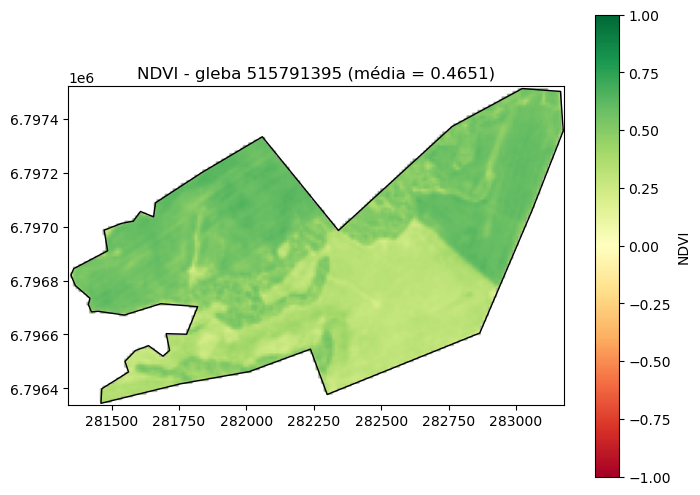

In [113]:
from rasterio.plot import show

ndvi_plot = np.ma.masked_equal(ndvi_clip[0], -9999)

fig, ax = plt.subplots(figsize=(8, 6))
img = show(ndvi_plot, transform=transform, ax=ax, cmap="RdYlGn", vmin=-1, vmax=1)
gleba_crsraster.boundary.plot(ax=ax, color="black", linewidth=1)
fig.colorbar(img.get_images()[0], ax=ax, label="NDVI")
ax.set_title(f"NDVI - gleba {ref_bacen} (média = {ndvi_mean:.4f})" if False else f"NDVI - gleba {ref_bacen} (média = {np.mean(values):.4f})")
plt.show()

---
# Summary

| Task | Command line | GDAL Python | Rasterio / GeoPandas |
|---|---|---|---|
| vector metadata | `ogrinfo -so -al` | `gdal.VectorInfo` / `ogr.Open` | `gpd.read_file`, `.crs`, `.total_bounds` |
| convert/reproject vector | `ogr2ogr -t_srs` | `gdal.VectorTranslate` | `.to_crs()`, `.to_file()` |
| raster metadata | `gdalinfo -stats` | `gdal.Open`, `gdal.Info` | `src.profile`, `src.crs`, `src.transform` |
| convert/subset raster | `gdal_translate` | `gdal.Translate` | `read(window=...)` + `rasterio.open(..., "w")` |
| reproject raster | `gdalwarp -t_srs` | `gdal.Warp` | `rasterio.warp.reproject` |
| mosaic | `gdal_merge.py`, `gdalbuildvrt` | `gdal.BuildVRT` | `rasterio.merge.merge` |
| band math | `gdal_calc.py` | NumPy | NumPy |

**Take-home messages**

1. A raster is a **NumPy array + georeferencing** (transform + CRS + nodata).
2. A vector layer is a **table + geometries + CRS** (GeoDataFrame).
3. Always know **which CRS** you are in — measure in projected CRSs, store/exchange in geographic ones.
4. **Nodata** must be handled explicitly (masks / masked arrays / NaN).
5. Prefer **vectorized** operations over loops, and **windows** for data that does not fit in memory.
6. GDAL/OGR is the engine behind everything: the CLI tools are perfect for automation and quick inspection.